In [ ]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [1]:
import pylab as plt
import SimpleITK as sitk
from skimage.data import horse

from graphomics import SkeletonizeImageFilter
from graphomics import GraphThicknessImageFilter

## Graphomics Semantic Segmentation - 2D

Demo of the `GraphThicknessImageFilter` applied for the semantic segmentation task of 2D inputs.

In this demo we will see how we can use the information extracted by the filter as kick-starter for a semantic segmentation task.
The following example is just a proof-of-concept and the results obtained on the sample image are just a demo.
The proposed pipeline, indeed, is totally agnostic by any information about the semantics.

For this demo we will use the data sample provided by the `skimage` library: in particular we will use the standard binary image of the `horse` layout.
In this case there are no pre-determined semantic areas, but we can easily predict the possibility to split the horse shape considering its limbs, tail, head, and ears.

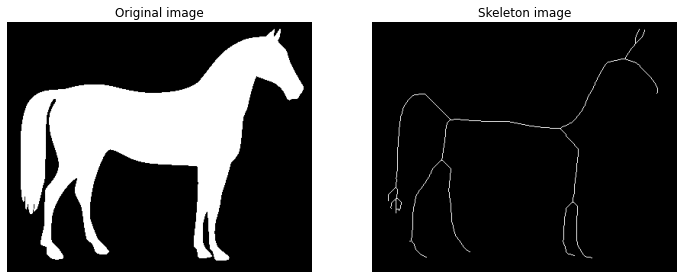

In [15]:
import numpy as np
from skimage.data import horse

# Invert the horse image
image = np.int32(~horse())
# convert it to the SimpleITK fmt
sitk_image = sitk.GetImageFromArray(image)

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(sitk_image)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

# retro-transform the output to Numpy
np_skeleton = sitk.GetArrayFromImage(skeleton)

# display the results
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6),
                               sharex=True, sharey=True)
_ = ax1.imshow(image, cmap='gray')
_ = ax1.axis('off')
_ = ax1.set_title('Original image')

_ = ax2.imshow(np_skeleton, cmap='gray')
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton image')

Starting from the skeleton image backbone, the purpose of the `Graphomics` is to extract and analyze the underlying graph.
To this purpose we can directly apply the `GraphThicknessImageFilter` and evaluate the extracted network.
In this demo we will particularly focuse on the `edgeMap` produced by the filter.

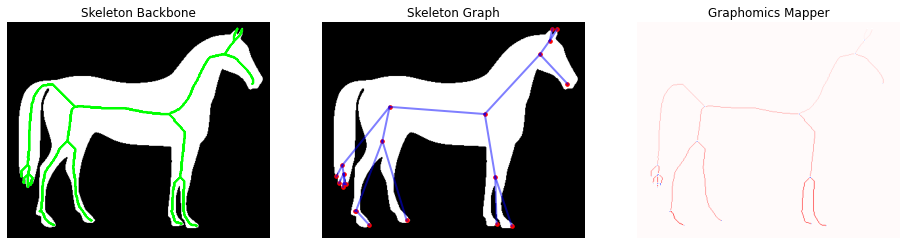

In [16]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(ndim=2,
                                      # number of dimension of the image
                                      surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=True
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

# transform the edgeMap to Numpy fmt
np_edgeMap = sitk.GetArrayFromImage(edgeMap)

# display the results
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 6),
                                    sharex=True, sharey=True)
_ = ax1.imshow(image, cmap='gray')
_ = ax1.contour(np_skeleton, colors='lime', linewidths=1)
_ = ax1.axis('off')
_ = ax1.set_title('Skeleton Backbone')

_ = ax2.imshow(image, cmap='gray')
_ = ax2.scatter(*zip(*nodes), facecolor='red', marker='.', s=50)
for ex, ey in edges:
    ax2.plot(*zip(*(ex, ey)), color='blue', linewidth=2, alpha=.5)
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton Graph')

_ = ax3.imshow(np_edgeMap, cmap='bwr')
_ = ax3.axis('off')
_ = ax3.set_title('Graphomics Mapper')

For sake of clarity, we report in the following the definition of the `edgeMap` (or `Graphomics Mapper`) computed by the filter:

    The edgeMap image/volume has the same size of the original input, in which
    each edge component is labelled with a different index:
        ° 0    values identify the background.
        ° > 0  values identify the labeled edges found
        ° < -1 values identify the labeled hyper-nodes found

According to this nomenclature we can easily extract a binary mask with only the nodes locations or with only the edge locations.
In this case we are interested in this second option, since the edge curves could be used as starting point for a semantic segmentation of the macro-areas which define the horse shape.
In particular, the `Watershed` algorithm (a standard technique for the semantic segmentation) application relies on the availability of robust markers for the identification of the different ROIs.

In this case we will use the edge mask as initial seed points in a `Watershed` segmentation producing the resulting semantic segmentation of the 2D input image. 

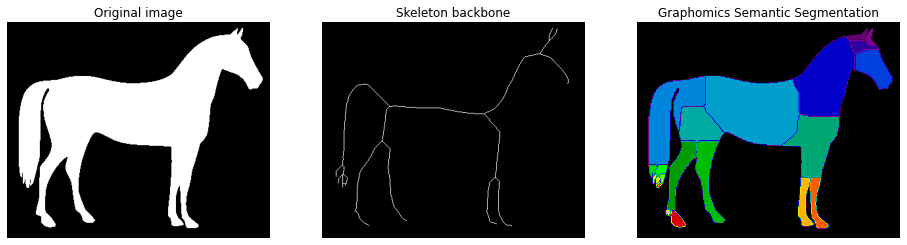

In [18]:
# extract the marker mask filtering the mapper and
# selecting only the positive values, i.e. the edge markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=0,
  upper=len(edges),
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=markers,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk.GetImageFromArray(image),
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg = sitk.GetArrayFromImage(ws)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 8))

_ = ax1.imshow(image, cmap='gray')
_ = ax1.axis('off')
_ = ax1.set_title('Original image')

_ = ax2.imshow(np_skeleton, cmap='gray')
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton backbone')

_ = ax3.imshow(semantic_seg, cmap='nipy_spectral')
_ = ax3.axis('off')
_ = ax3.set_title('Graphomics Semantic Segmentation')

We would like to stress that in this case there is no a ground truth about the semantic segmentation, but the possibility to use `Graphomics` output for semantic segmentation tasks extends the potentiality of the proposed technique.

⚠️ **NOTE:** The approach proposed above could be used for the estimation of the graph's weights in the skeleton backbone.
For this reason, the `Graphomics` package provides a ready-to-use implementation of this technique into the list of possible `graph_weights` algorithms (ref. `graphomics/_graph.py` for developer details)

## Graphomics Semantic Segmentation - 3D

Demo of the `GraphThicknessImageFilter` applied for the semantic segmentation task of 3D inputs.
